In [69]:
import pandas as pd
import matplotlib.pyplot as plt
# import matplotlib.dates as mdates

# Load CSV
df = pd.read_csv("room_data.csv")

# Display first few rows
print(df.head())

# Check missing values
print("\nMissing values:")
print(df.isnull().sum())

# Check duplicates
print("\nDuplicate rows:")
print(df.duplicated().sum())

# Check data information
print("\nDataset information:")
print(df.info())

# Convert timestamp to datetime
df["Timestamp"] = pd.to_datetime(df["Timestamp"])

# Convert sensor values to numeric
df["Humidity (%)"] = pd.to_numeric(df["Humidity (%)"])
df["Temperature (°C)"] = pd.to_numeric(df["Temperature (°C)"])


# Basic statistics
print("\nBasic statistics:")
print(df.describe())

             Timestamp  Humidity (%)  Temperature (°C)
0  2026-07-30 17:48:15          56.1              21.4
1  2026-07-30 17:48:30          56.1              21.4
2  2026-07-30 17:48:45          56.1              21.4
3  2026-07-30 17:49:00          56.0              21.4
4  2026-07-30 17:49:15          56.0              21.4

Missing values:
Timestamp           0
Humidity (%)        0
Temperature (°C)    0
dtype: int64

Duplicate rows:
0

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 241 entries, 0 to 240
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Timestamp         241 non-null    object 
 1   Humidity (%)      241 non-null    float64
 2   Temperature (°C)  241 non-null    float64
dtypes: float64(2), object(1)
memory usage: 5.8+ KB
None

Basic statistics:
                           Timestamp  Humidity (%)  Temperature (°C)
count                            241    241.00000

In [93]:
# Create table with my focus score
focus_data = {
    "Time": [
        "17:48:15",
        "17:53:15",
        "17:58:15",
        "18:03:15",
        "18:08:15",
        "18:13:15",
        "18:18:15",
        "18:23:15",
        "18:28:15",
        "18:33:15",
        "18:38:15",
        "18:43:15",
        "18:48:15"
    ],
    "Focus Score": [
        8,
        7,
        7,
        6,
        8,
        8,
        7,
        7,
        6,
        6,
        5,
        5,
        4
    ]
}

focus_df = pd.DataFrame(focus_data)
focus_df

,Time,Focus Score
0,17:48:15,8
1,17:53:15,7
2,17:58:15,7
3,18:03:15,6
4,18:08:15,8
5,18:13:15,8
6,18:18:15,7
7,18:23:15,7
8,18:28:15,6
9,18:33:15,6


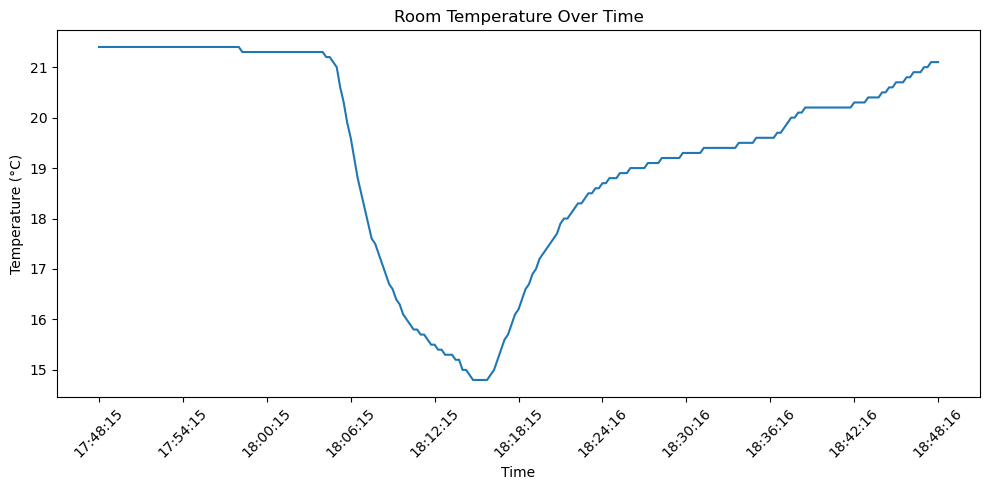

In [111]:
# Create time column for display
df["Time"] = df["Timestamp"].dt.strftime("%H:%M:%S")

plt.figure(figsize=(10,5))

# Temperature time series plot
plt.plot(
    df["Time"],
    df["Temperature (°C)"],
    label="Temperature (°C)"
)

# Labels and title
plt.xlabel("Time")
plt.ylabel("Temperature (°C)")
plt.title("Room Temperature Over Time")

# Display 10 (not including the start) time intervals
tick_positions = range(0, len(df), len(df)//10)

plt.xticks(
    tick_positions,
    df["Time"].iloc[tick_positions],
    rotation=45
)

plt.tight_layout()
plt.show()

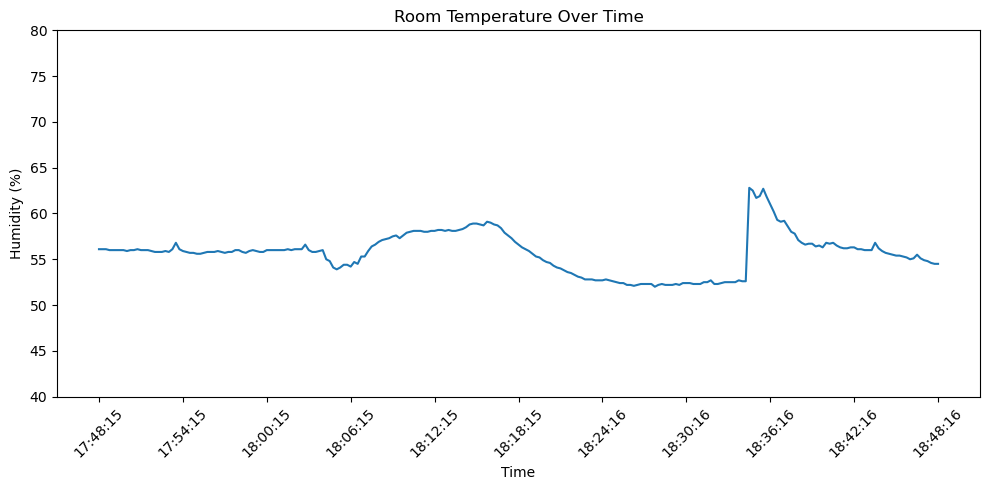

In [115]:
plt.figure(figsize=(10,5))

# Temperature time series plot
plt.plot(
    df["Time"],
    df["Humidity (%)"],
    label="Humidity (%)"
)

# Labels, range, and title
plt.xlabel("Time")
plt.ylabel("Humidity (%)")
plt.ylim(40,80)
plt.title("Room Temperature Over Time")

# Display 10 (not including the start) time intervals
tick_positions = range(0, len(df), len(df)//10)

plt.xticks(
    tick_positions,
    df["Time"].iloc[tick_positions],
    rotation=45
)

plt.tight_layout()
plt.show()

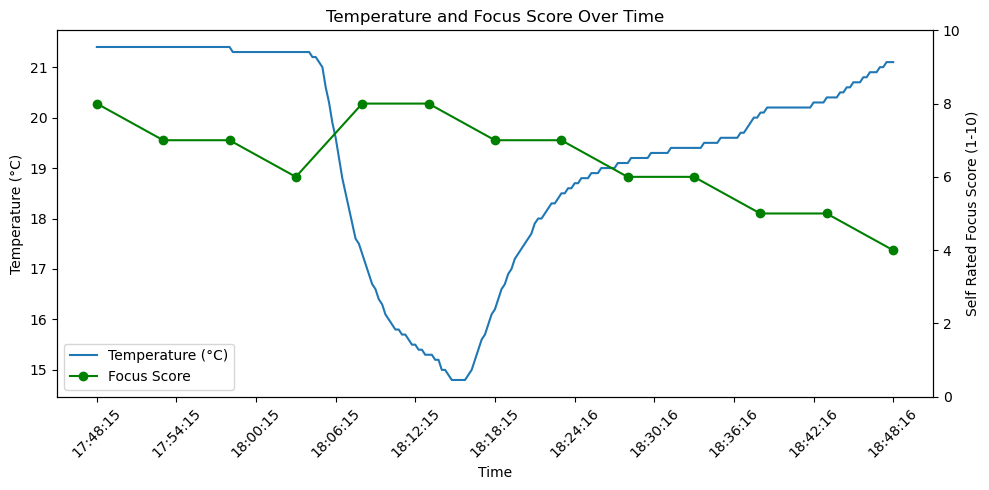

In [107]:
# Create focus timestamps every 5 minutes from the first temperature reading
focus_df["Time"] = pd.date_range(
    start=df["Timestamp"].iloc[0],
    periods=len(focus_df),
    freq="5min"
)

# Create figure and first y-axis
fig, ax1 = plt.subplots(figsize=(10, 5))

# Temperature plot
ax1.plot(
    df["Timestamp"],
    df["Temperature (°C)"],
    label="Temperature (°C)"
)

# Label axis
ax1.set_xlabel("Time")
ax1.set_ylabel("Temperature (°C)")

# Create second y-axis
ax2 = ax1.twinx()

# Focus score plot
ax2.plot(
    focus_df["Time"],
    focus_df["Focus Score"],
    marker="o",
    color="green",
    label="Focus Score"
)

# Set label and range for axis
ax2.set_ylabel("Self Rated Focus Score (1-10)")
ax2.set_ylim(0, 10)

# Display 10 (not including the start) time intervals
tick_positions = range(0, len(df), len(df)//10)

ax1.set_xticks(
    df["Timestamp"].iloc[tick_positions]
)

# Format time as HH:MM:SS for clearability
ax1.set_xticklabels(
    df["Timestamp"].iloc[tick_positions].dt.strftime("%H:%M:%S"),
    rotation=45
)

# Combine legends
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines_1 + lines_2,
    labels_1 + labels_2,
    loc="best"
)

plt.title("Temperature and Focus Score Over Time")

plt.tight_layout()
plt.show()

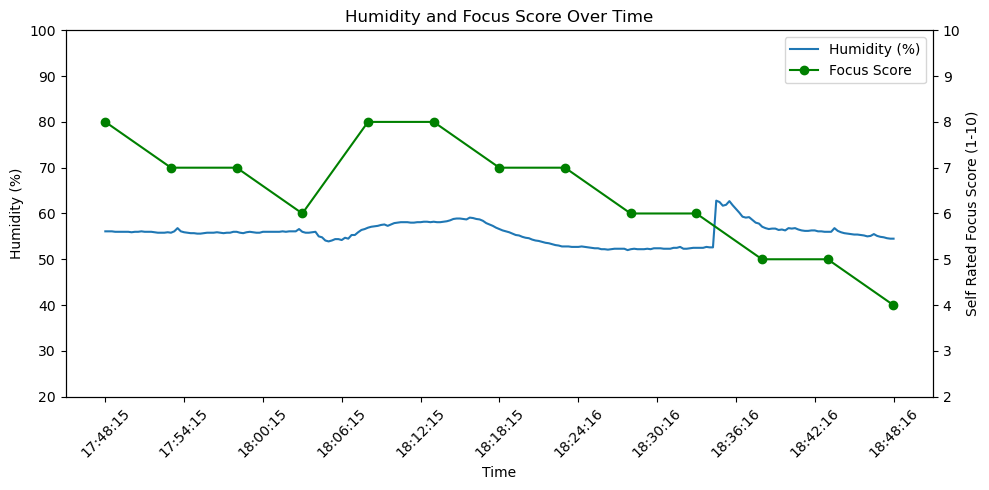

In [116]:
# Create focus timestamps every 5 minutes from the first temperature reading
focus_df["Time"] = pd.date_range(
    start=df["Timestamp"].iloc[0],
    periods=len(focus_df),
    freq="5min"
)

# Create figure and first y-axis
fig, ax1 = plt.subplots(figsize=(10, 5))

# Humidity plot
ax1.plot(
    df["Timestamp"],
    df["Humidity (%)"],
    label="Humidity (%)"
)

# Set Label and range for axis
ax1.set_xlabel("Time")
ax1.set_ylabel("Humidity (%)")
ax1.set_ylim(20,100)

# Create second y-axis
ax2 = ax1.twinx()

# Focus score plot
ax2.plot(
    focus_df["Timestamp"],
    focus_df["Focus Score"],
    marker="o",
    color="green",
    label="Focus Score"
)

# Set label and range for axis
ax2.set_ylabel("Self Rated Focus Score (1-10)")
ax2.set_ylim(2, 10)

# Display 10 (not including the start) time intervals
tick_positions = range(0, len(df), len(df)//10)

ax1.set_xticks(
    df["Timestamp"].iloc[tick_positions]
)

# Format time as HH:MM:SS for clearability
ax1.set_xticklabels(
    df["Timestamp"].iloc[tick_positions].dt.strftime("%H:%M:%S"),
    rotation=45
)

# Combine legends
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines_1 + lines_2,
    labels_1 + labels_2,
    loc="best"
)

plt.title("Humidity and Focus Score Over Time")

plt.tight_layout()
plt.show()